# Aligning Spatial Glycomics and IHC images

*Author: [Andrew Causer](https://agc888.github.io/OspreyAI)*

This notebook is a tutorial of how to use *goatpy* to align IHC images with spatial glycomics data. For more infomation on image alignment with *goatpy* please visit the [Getting Started](https://goatpy.readthedocs.io/en/latest/guides/getting_started.html#Loading-and-Aligning-Data) page.

Similar to using a H&E image, IHC images can be aligned to Glycomics data with *goatpy* using either a manual or automatic method.

In [1]:
import goatpy as gp
import spatialdata_plot
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import squidpy as sq
from napari_spatialdata import Interactive

/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## Manual Alignment

Manual alignment involves the use of [SpatialData-Napari](https://spatialdata.scverse.org/projects/napari/en/latest/notebooks/spatialdata.html). First we need to contruct two SpatialData objects using *goatpy*:

1. Spatial Glycomics Object (MALDI-MSI)
2. Imaging Data Object (IHC)

Lets do this below:

In [2]:
## Create MALDI-MSI SpatialData object
maldi_sd = gp.glyco_spatialdata(imzml_path="/Users/andrewcauser/Documents/Griffith/test_data/IHC_new/ad_dm_sa_deriv_19pm0001_0204002_reduced_peakonly.imzML")

## Create IHC SpatialData object
ihc_sd = gp.ihc_spatialdata("/Users/andrewcauser/Documents/Griffith/test_data/IHC_new/DM_22.05.26_Image_2_19PM0001_RedGrnChannel.tif")

/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is dep

Loaded image with shape: (1341, 1508, 3)
Successfully generated SpatialData object


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/models/models.py:1144: UserWarning: Converting `region_key: region` to categorical dtype.
  return convert_region_column_to_categorical(adata)


We can visualise the data structure of these two objects:

In [3]:
maldi_sd

SpatialData object
├── Points
│     └── 'centroids': DataFrame with shape: (<Delayed>, 112) (2D points)
├── Shapes
│     └── 'pixels': GeoDataFrame shape: (117948, 2) (2D shapes)
└── Tables
      └── 'maldi_adata': AnnData (117948, 108)
with coordinate systems:
    ▸ 'global', with elements:
        centroids (Points), pixels (Shapes)

In [4]:
ihc_sd

SpatialData object
└── Images
      └── 'ihc_image': DataArray[cyx] (3, 1341, 1508)
with coordinate systems:
    ▸ 'global', with elements:
        ihc_image (Images)

Following the same method as H&E manual alignment we must generate a psuedo-image for our MALDI-MSI data:

In [5]:
maldi_sd = gp.Add_Pseudo_Image(maldi_sd, "MPI", tables = "maldi_adata", library_id = "Spatial", is_continous=True, cmap = "viridis",img_upscaling=2)

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:118: UserWarning: Key `centroids` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Transposing `data` of type: <class 'dask.array.core.Array'> to ('c', 'y', 'x').                           


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


Now we can run *goatpy's* manual alignment GUI to select corresponding landmarks on the pseudo-MSI and IHC image. Below is a screenshot showing the layout of the single window GUI:

In [ ]:
viewer, widget = gp.launch_landmark_gui(maldi_sd, ihc_sd, split_view=False,  he_image_key = "ihc_image")

<img src="../_static/tutorial_images/alignment_gui_screenshot.png" width="1000">


The below section of code is for reproducability. These are the location of 4 landmarks on the MALDI-MSI and IHC coordinate system, respectively.

In [7]:
from spatialdata.models import PointsModel
import pandas as pd

maldi_align_points = pd.DataFrame({
    "x": [56.691345,172.349422,577.152689,997.829025,],
    "y": [483.286246,166.483689,322.370662,597.166866]
})

ihc_align_points = pd.DataFrame({
    "x": [129.072657,318.347858,834.765384,1318.743398],
    "y": [669.121976,267.204264,503.214083,870.946993]
})

maldi_sd["maldi_landmarks"] = PointsModel.parse(maldi_align_points)
ihc_sd["ihc_landmarks"] = PointsModel.parse(ihc_align_points)

Following the selection of these landmarks we can run the alignment function. 

NOTE: Make sure the correct image keys are used if changed between H&E and IHC images.

In [8]:
aligned = gp.align_image_using_landmarks(maldi_sd, ihc_sd, he_image_key = "ihc_image", he_landmark_key = "ihc_landmarks")

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


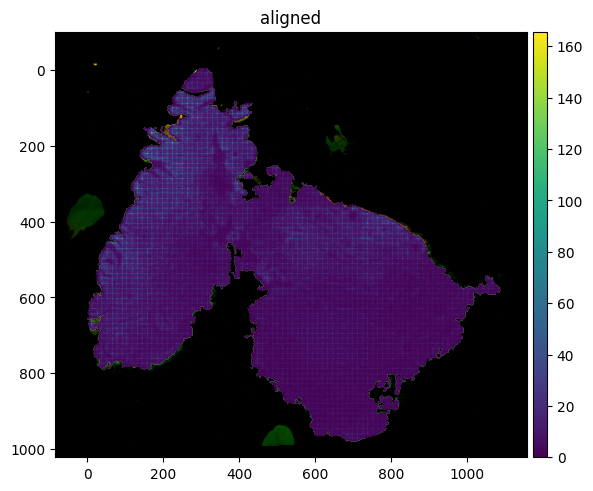

In [9]:
aligned.pl.render_images("ihc_image") \
       .pl.render_shapes("pixels", color="MPI", size =50) \
       .pl.show("aligned")

From the figure above we can see the alignment has worked well.

## Automatic Alignment

Similar to H&E, we can also run automatic alignment with the IHC image. Lets run this below, providing the .imzML, IHC image and peaks list file path.

In [10]:
sdata = gp.load_and_align(imzml_path="/Users/andrewcauser/Documents/Griffith/test_data/IHC_new/ad_dm_sa_deriv_19pm0001_0204002_reduced_peakonly.imzML", 
               ihc_path="/Users/andrewcauser/Documents/Griffith/test_data/IHC_new/DM_22.05.26_Image_2_19PM0001_RedGrnChannel.tif",
               peaks_path="/Users/andrewcauser/Documents/Griffith/test_data/IHC_new/Sample 19M0001 glycan list.csv")

[0.23GB] Loading peaks ...
[0.24GB]   174 peaks
[0.24GB]   IHC pixel size from ImageJ TIFF tags (ResolutionUnit=1, unit=µm): 7.8000 um/px  (XResolution=0.128205 px/µm)
[0.24GB]   IHC native pixel size: 7.8000 um/px


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/pyimzml/ontology/ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size x". Updating name to "pixel size (x)".
  warn(


[0.29GB]   MALDI pixel size from imzML metadata: 20.0 um/px
[0.25GB]   Validated: ref thumbnail (588x523 px) >= MALDI (544x492 px)
[0.25GB]   maldi_pixel_um=20.0  ref_pixel_um=7.8000
[0.25GB] Computing MALDI crop offsets ...
[0.30GB]   Crop: row=0, col=0
[0.70GB] Loading 174 ion images (chunk=10) with 0.1 Da tolerance per peak ...


/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/andrewcauser/goatpy/goatpy/io.py:7: UserWarning: pkg_resources is dep

[0.44GB]   Peaks 1-10 / 174
[0.44GB]   Peaks 11-20 / 174
[0.45GB]   Peaks 21-30 / 174
[0.46GB]   Peaks 31-40 / 174
[0.44GB]   Peaks 41-50 / 174
[0.43GB]   Peaks 51-60 / 174
[0.44GB]   Peaks 61-70 / 174
[0.43GB]   Peaks 71-80 / 174
[0.43GB]   Peaks 81-90 / 174
[0.43GB]   Peaks 91-100 / 174
[0.46GB]   Peaks 101-110 / 174
[0.43GB]   Peaks 111-120 / 174
[0.46GB]   Peaks 121-130 / 174
[0.32GB]   Peaks 131-140 / 174
[0.32GB]   Peaks 141-150 / 174
[0.29GB]   Peaks 151-160 / 174
[0.31GB]   Peaks 161-170 / 174
[0.32GB]   Peaks 171-174 / 174
[0.35GB]   spectra_all: (492, 544, 174)  (186 MB)
[0.35GB] Preparing MALDI template ...
[0.35GB]   MALDI grayscale: (492, 544)  mean=0.192
[0.74GB] Loading IHC at 20.0 um/px ...
[0.74GB]   Loading IHC: /Users/andrewcauser/Documents/Griffith/test_data/IHC_new/DM_22.05.26_Image_2_19PM0001_RedGrnChannel.tif
[0.74GB]   Raw array shape: (1341, 1508, 3)  dtype=uint8  axes='YXS'
[0.74GB]   Normalised to (C,H,W): (3, 1341, 1508)
[0.74GB]   Channel names: ['CF_405', 

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


[1.42GB]   IHC upscaled 10x: (3, 7030, 7640)  (161 MB)
[1.41GB]   IHC image stored: channels=['CF_405', 'CF_488', 'CF_561']
[1.43GB]   Transform stored: mode=ihc  rotation=-3.0  ref_reg_size=[523, 588]  canvas_placement=[75, 75]
[1.43GB] Done.


In [11]:
sdata

SpatialData object
├── Images
│     └── 'ihc_image': DataArray[cyx] (3, 7030, 7640)
├── Points
│     └── 'centroids': DataFrame with shape: (<Delayed>, 3) (2D points)
├── Shapes
│     └── 'pixels': GeoDataFrame shape: (267648, 2) (2D shapes)
└── Tables
      └── 'maldi_adata': AnnData (267648, 174)
with coordinate systems:
    ▸ 'global', with elements:
        ihc_image (Images), centroids (Points), pixels (Shapes)

INFO     Rasterizing image for faster rendering.                                                                   


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


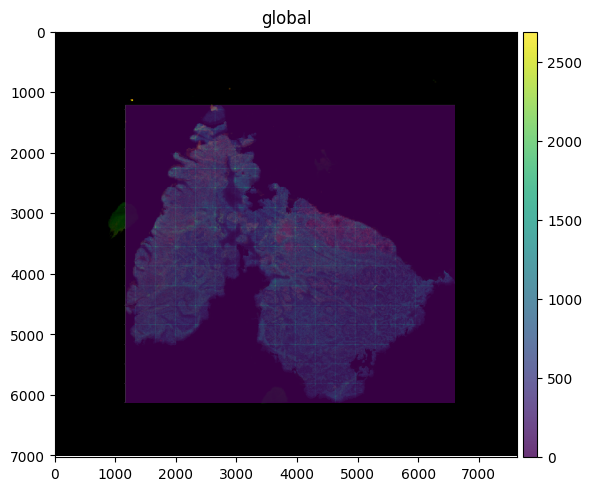

In [13]:
sdata.pl.render_images("ihc_image") \
     .pl.render_shapes("pixels", color="MPI", fill_alpha = 0.8) \
     .pl.show()

## Spatially Informed Clustering (GraphPCA)

*goatpy* has also integrated the use of GraphPCA spatial clustering. Spatial infomation can often improve clustering compared to non-spatial methods (i.e. leiden).

Below we will run spatial_clustering and visualise the results overlayed with the IHC image:

In [19]:
sdata = gp.graphpca_spatialdata(sdata, tables= "maldi_adata",
    library_id= 'spatial',
    n_components = 50, 
    n_neighbors = 15,
    alpha = 0.5)

sdata = gp.get_kmean_clusters(sdata, tables= "maldi_adata",n_clusters = 12) 

INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata_plot/pl/utils.py:800: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


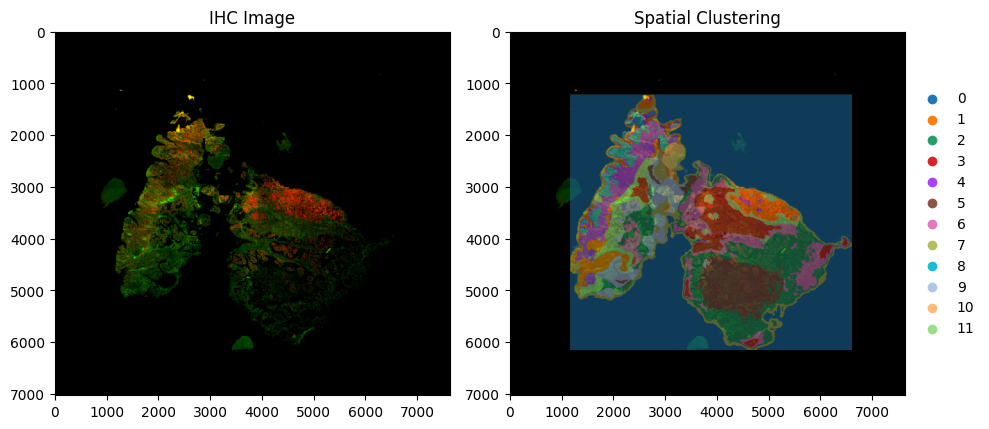

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sdata.pl.render_images("ihc_image") \
     .pl.show(ax=axes[0], title="IHC Image")

sdata.pl.render_images("ihc_image") \
     .pl.render_shapes("pixels",size = 3,fill_alpha = 0.5,color="GPCA_clusters") \
     .pl.show(ax=axes[1], title="Spatial Clustering")

plt.tight_layout()
plt.show()


In [18]:
import matplotlib.pyplot as plt

ax = (
    sdata.pl.render_images("ihc_image")
    .pl.render_shapes(
        "pixels",
        color="MPI",
        fill_alpha=0.8
    )
    .pl.show(return_ax=True)
)

plt.savefig(
    "/Users/andrewcauser/Downloads/my_spatial_plot.pdf",
    bbox_inches="tight"
)

plt.close()

INFO     Rasterizing image for faster rendering.                                                                   


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `pixels` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `maldi_adata` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


This object can now be used to run downstream analysis using *goatpy* or any other package:

## Tutorial Session Info

In [20]:
from session_info import show
show()

/Users/andrewcauser/anaconda3/envs/maldi_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
